using autoencoder model
              precision    recall  f1-score   support

     Negativ       1.00      0.97      0.98      7141
     Positiv       0.70      0.96      0.81       585

    accuracy                           0.97      7726
   macro avg       0.85      0.96      0.89      7726
weighted avg       0.97      0.97      0.97      7726

[[6894  247]
 [  22  563]]
Nya positiva till följd av fria lätta kedjor: 15
AUC: 0.9898096582034408
Accuracy:  96.52%
FN-rate:   3.76%  (farliga missade fall)
FP-rate:   3.46%  (onödiga larm)
Sensitivitet:   96.24%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   96.54%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9898


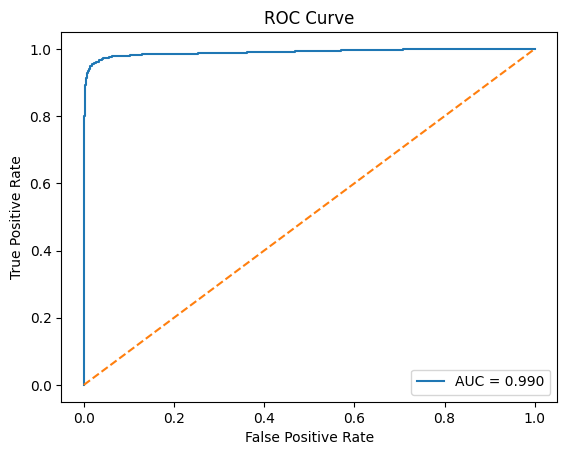

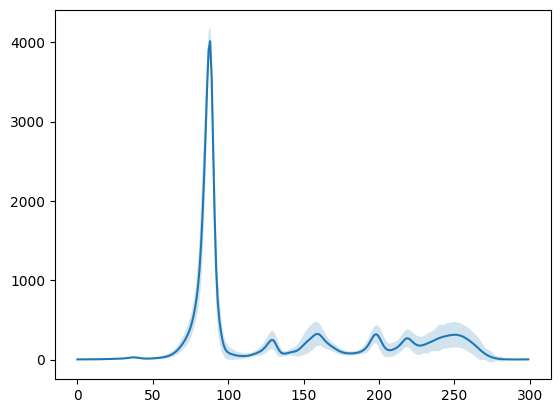

In [1]:
import duckdb
from functions.analyte import ANALYTES
from networks.cnn_dilated_convolutions import CNNModel
from networks.auto_encoder import AutoencoderModel
from functions.evaluation import evaluate
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from networks.oligoclonal_network import OligoclonalModel
from networks.inflammation_network import InflammationModel
from functions.free_light_chains import predict_using_free_light_chains

con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT id, age, gender, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm,s_kappa,s_lambda,s_kl_kvot,label, set, interpretation
                 FROM protein_data 
                 WHERE value IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 AND observation_nr = 1
                 """).df()

pids = con.execute("SELECT DISTINCT pid FROM protein_data").df()


con.close()

df = df[
    (df['fractions'].apply(len) == 6) &
    (df['boundaries'].apply(len) == 12)
]

protein_cols = [a.col for a in ANALYTES[:8]]  # bara de 8 första
df = df.dropna(subset=protein_cols)
y = df['label']

df = df[df['set'] == 'test']
cnn = CNNModel()
ae = AutoencoderModel()
df = cnn.predict(df)
df = ae.predict(df)
df = InflammationModel().predict(df)
df = OligoclonalModel().predict(df)
df['alarming_free_light_chains'] = df['s_kl_kvot'].apply(
    lambda x: predict_using_free_light_chains(x) if pd.notna(x) else 0
    )
df = evaluate(df[ (df['label'] == 0 ) | (df['label'] == 1)],threshold=0.2,proportion=70)

stats = pd.DataFrame()
x_avg = np.concatenate([
    np.stack(df['value'].values).mean(axis=0),   # (300,)
    np.stack(df['fractions'].values).mean(axis=0),                      # (6,)
    np.stack(df['boundaries'].values).mean(axis=0),                      # (12,)
    df[protein_cols].mean(axis=0)                        # (8,)
]) 

x_std = np.concatenate([
    np.stack(df['value'].values).std(axis=0),   # (300,)
    np.stack(df['fractions'].values).std(axis=0),                      # (6,)
    np.stack(df['boundaries'].values).std(axis=0),                      # (12,)
    df[protein_cols].std(axis=0)                        # (8,)
]) 

stats['avg'] = x_avg
stats['std'] = x_std
stats.to_csv('statistics_overview.csv')
plt.figure()
plt.plot(range(300),stats['avg'][0:300])
plt.fill_between(range(300),x_avg[0:300]-x_std[0:300],x_avg[0:300]+x_std[0:300],alpha=0.2)
plt.show()

19.4


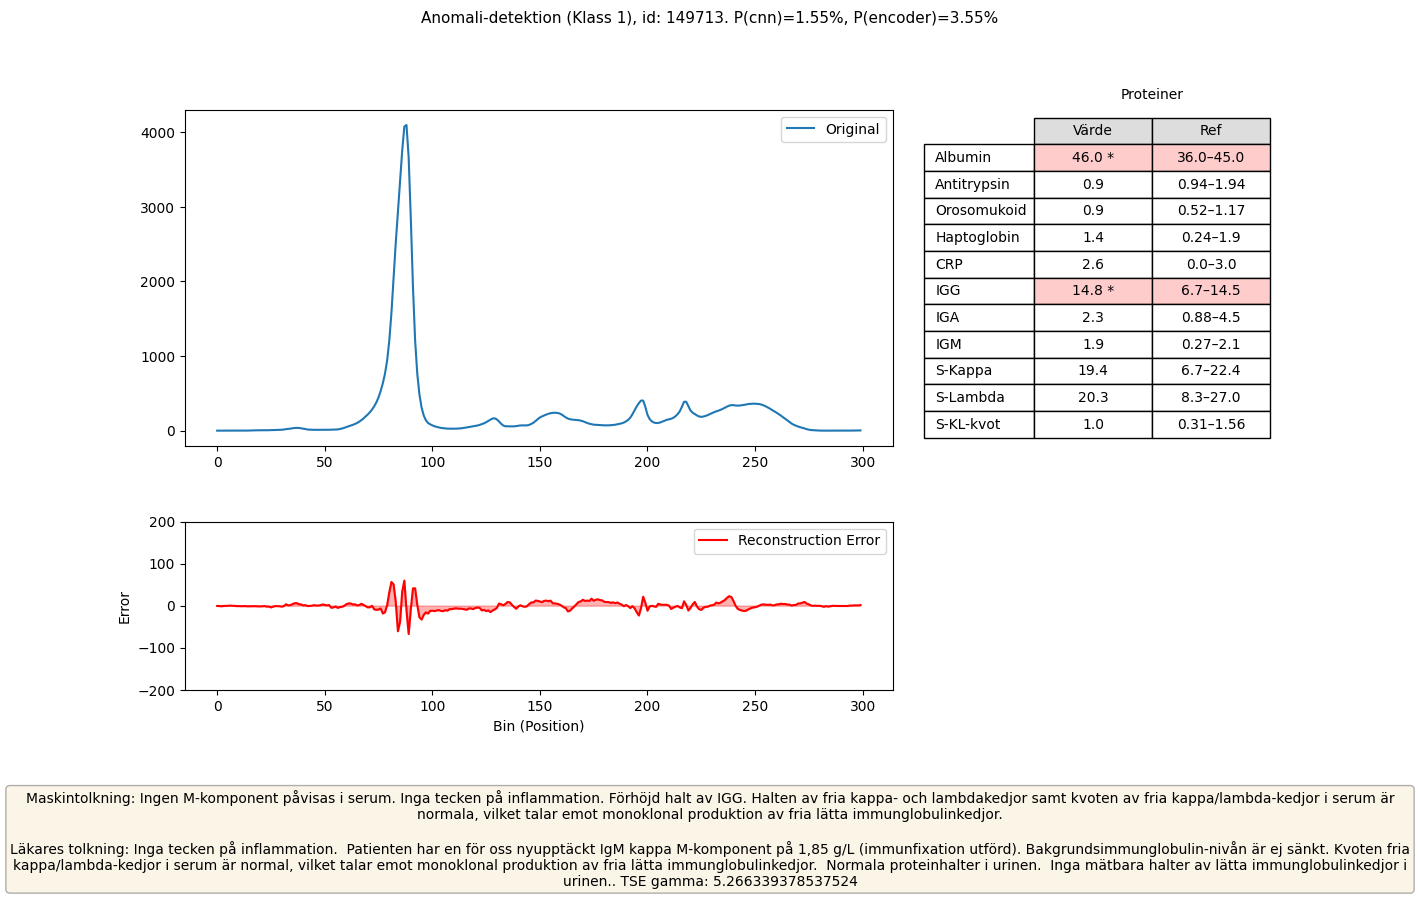

In [18]:
import importlib
import functions.full_model as full_model
importlib.reload(full_model)
from functions.full_model import interpret


#df = evaluate(df[ (df['label'] == 0 ) | (df['label'] == 1)],threshold = 0.15,proportion=50)

#df['prediction'] = ((df['cnn_probability'] > 0.15) | (df['proportion_gamma_region'] > 0.5)).astype(int)

#rows = processed_rows[processed_rows['proportion_gamma_region'] > 0.9].sort_values('proportion_gamma_region',ascending=False)
row = df[ (df['final_prediction'] == 0) & (df['label'] == 1)].iloc[12]
result = interpret(row.to_dict())

# aucs = np.stack(df['value'].values).sum(axis=1)
# print(f"Max:    {aucs.max():.1f}")
# print(f"Mean:   {aucs.mean():.1f}")
# print(f"Median: {np.median(aucs):.1f}")
# print(f"95e percentilen {np.percentile(aucs, 95)}")
